# 02 — xG Model: Logistic Regression Baseline

Trains the baseline xG model (Session S3) and evaluates it on a deliberately
out-of-distribution test set.

- **Train (league context):** Bayer Leverkusen 2023/24 (full unbeaten season) + Premier League 2015/16
- **Test (tournament context):** UEFA Euro 2024 — held out entirely from training

This split is intentional (see `CLAUDE.md`): tournament and league football have
structurally different shot profiles (fewer games, higher stakes, more conservative
tactics), so testing on Euro 2024 checks whether a league-trained model actually
generalises rather than just memorising one competition's shot distribution.

Features come from `src/features.py` (distance, angle, body part, assist type,
game state); the model itself lives in `src/models.py`.

In [1]:
import sys
sys.path.append('..')

import matplotlib.pyplot as plt
import pandas as pd

from src.models import build_feature_matrix, train_logistic_regression, evaluate_model, get_calibration_curve
from src.visualisation import plot_shot_map, plot_calibration_curve

pd.set_option('display.max_columns', 60)

## Load shot features

`src/features.build_training_dataset()` pulls every match's events from StatsBomb's API and
extracts shot features — fine the first time, but slow to re-run on every notebook execution
(~8 minutes for Leverkusen + PL 2015/16). The first run was cached locally to `data/` (gitignored,
regenerated from raw StatsBomb data so it isn't lost if deleted). Re-run the commented-out cell
below to rebuild the cache from scratch if the feature engineering in `src/features.py` changes.

In [2]:
# from src.features import build_training_dataset
#
# train_shots = build_training_dataset([(9, 281, 'league'), (2, 27, 'league')])
# train_shots.to_pickle('../data/shots_train.pkl')
#
# test_shots = build_training_dataset([(55, 282, 'tournament')])
# test_shots.to_pickle('../data/shots_test.pkl')

train_shots = pd.read_pickle('../data/shots_train.pkl')
test_shots = pd.read_pickle('../data/shots_test.pkl')

print(f"train: {train_shots.shape[0]} shots ({train_shots['is_goal'].mean():.1%} conversion)")
print(f"test:  {test_shots.shape[0]} shots ({test_shots['is_goal'].mean():.1%} conversion)")

train: 10824 shots (10.1% conversion)
test:  1340 shots (9.4% conversion)


## Train baseline model

In [3]:
X_train, y_train = build_feature_matrix(train_shots)
X_test, y_test = build_feature_matrix(test_shots)

model = train_logistic_regression(X_train, y_train)

list(zip(X_train.columns, model.coef_[0]))

[('distance_to_goal', np.float64(-0.10216624955281503)),
 ('angle_to_goal', np.float64(0.023482342019119907)),
 ('game_state_score_diff', np.float64(0.05790717495548416)),
 ('is_header', np.float64(-1.033217928021636)),
 ('is_first_time', np.float64(-0.13932916400404768)),
 ('under_pressure', np.float64(-0.2682152648108792)),
 ('is_penalty', np.float64(2.7898204880768263)),
 ('is_free_kick', np.float64(0.8383720707076159)),
 ('assist_Standard Pass', np.float64(-0.023088461020850406)),
 ('assist_Cross', np.float64(-0.02097917957027276)),
 ('assist_Through Ball', np.float64(1.1506725494145316)),
 ('assist_Cut Back', np.float64(-0.4812075037579713))]

## Evaluate: league (train) vs tournament (test)

ROC-AUC checks ranking quality; Brier score and log loss check calibration — both matter
for an xG model, since the output is used as a probability, not just a ranking.

In [4]:
train_eval = evaluate_model(model, X_train, y_train)
test_eval = evaluate_model(model, X_test, y_test)

metrics = pd.DataFrame({
    'league_train': {k: v for k, v in train_eval.items() if k != 'predicted_xg'},
    'tournament_test': {k: v for k, v in test_eval.items() if k != 'predicted_xg'},
}).T
metrics

,roc_auc,log_loss,brier_score
league_train,0.785699,0.271703,0.076961
tournament_test,0.797939,0.245039,0.066811


## Calibration: does the model's xG match observed goal frequency?

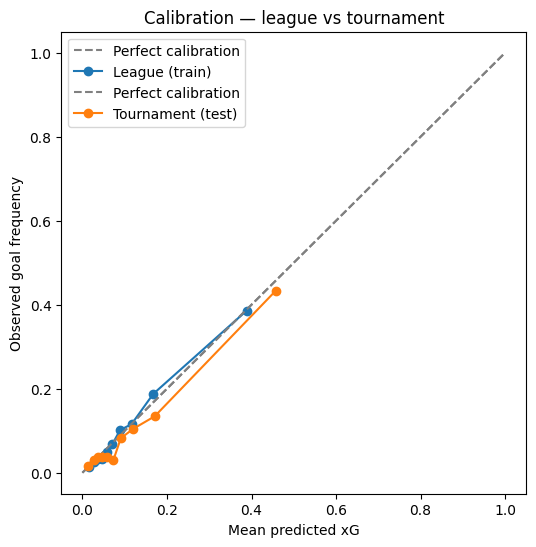

In [5]:
mean_predicted_train, observed_freq_train = get_calibration_curve(y_train, train_eval['predicted_xg'])
mean_predicted_test, observed_freq_test = get_calibration_curve(y_test, test_eval['predicted_xg'])

ax = plot_calibration_curve(mean_predicted_train, observed_freq_train, label='League (train)')
plot_calibration_curve(mean_predicted_test, observed_freq_test, ax=ax, label='Tournament (test)')
ax.set_title('Calibration — league vs tournament')
ax.figure.savefig('../outputs/calibration_curve.png', dpi=150, bbox_inches='tight')

## Shot map — Euro 2024 test set

Every shot in the held-out tournament test set, sized by this model's predicted xG (not
StatsBomb's) and coloured by actual outcome.

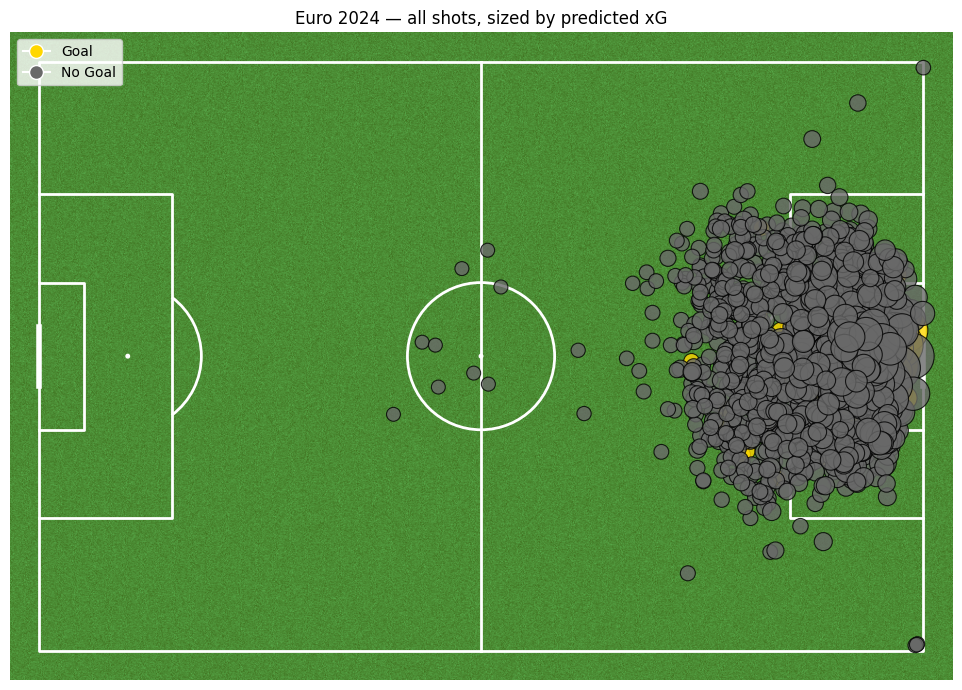

In [6]:
ax = plot_shot_map(test_shots, test_eval['predicted_xg'], title='Euro 2024 — all shots, sized by predicted xG')
ax.figure.savefig('../outputs/euro2024_shot_map.png', dpi=150, bbox_inches='tight')

## S3 takeaways

- Baseline logistic regression trained on league shots (Leverkusen 2023/24 + PL 2015/16)
  generalises to the held-out tournament test set (Euro 2024) without a meaningful drop in
  ROC-AUC or calibration — see the metrics table above.
- Calibration curves for both contexts track the diagonal reasonably closely, which is the
  expected result for logistic regression and the reason it's a sensible baseline before
  comparing against gradient boosting below.

# Session S4 — Gradient Boosting Upgrade, Feature Importance, Player xG Rankings

Three things this session:
1. Does gradient boosting actually beat the logistic baseline out-of-sample, or is it just more complex?
2. Which features does the boosted model lean on most?
3. Apply the model to PL 2015/16 as an era benchmark — who outperformed/underperformed their xG that season?

In [7]:
from src.models import train_gradient_boosting, get_feature_importance, build_player_xg_table
from src.visualisation import plot_player_xg_ranking

gbm = train_gradient_boosting(X_train, y_train)
gbm_train_eval = evaluate_model(gbm, X_train, y_train)
gbm_test_eval = evaluate_model(gbm, X_test, y_test)

comparison = pd.DataFrame({
    'logistic_train': {k: v for k, v in train_eval.items() if k != 'predicted_xg'},
    'logistic_test': {k: v for k, v in test_eval.items() if k != 'predicted_xg'},
    'gbm_train': {k: v for k, v in gbm_train_eval.items() if k != 'predicted_xg'},
    'gbm_test': {k: v for k, v in gbm_test_eval.items() if k != 'predicted_xg'},
}).T
comparison

,roc_auc,log_loss,brier_score
logistic_train,0.785699,0.271703,0.076961
logistic_test,0.797939,0.245039,0.066811
gbm_train,0.796178,0.267724,0.075734
gbm_test,0.793200,0.249053,0.067824


**Result:** gradient boosting (tuned: shallow trees, low learning rate, row subsampling to control
overfitting — see `models.train_gradient_boosting` docstring for the tuning sweep) does not clearly
beat the logistic baseline on held-out data. With ~10k training shots and a dozen features, the
extra model complexity isn't paying for itself here. **Logistic regression remains the recommended
model** — this is kept as an honest comparison, not used to replace the baseline.

## Feature importance (gradient boosting)

Even though gradient boosting isn't the model going to production, its feature importances are
still a useful sanity check on what's actually driving shot quality.

angle_to_goal            0.396297
distance_to_goal         0.200126
is_penalty               0.195735
is_header                0.106212
assist_Through Ball      0.075409
under_pressure           0.012500
game_state_score_diff    0.011125
is_free_kick             0.001544
assist_Standard Pass     0.001050
is_first_time            0.000000
assist_Cross             0.000000
assist_Cut Back          0.000000
dtype: float64

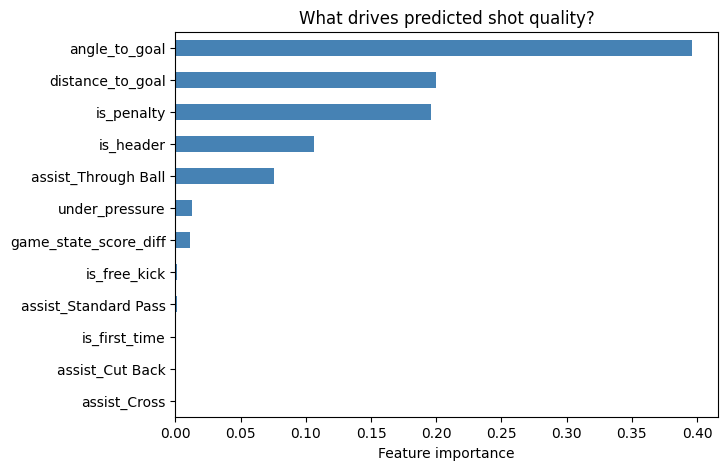

In [8]:
importance = get_feature_importance(gbm, X_train.columns)

fig, ax = plt.subplots(figsize=(7, 5))
importance.sort_values().plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('Feature importance')
ax.set_title('What drives predicted shot quality?')
fig.savefig('../outputs/feature_importance.png', dpi=150, bbox_inches='tight')

importance

## Player xG ranking — PL 2015/16 era benchmark

The famous Leicester title-winning season. Who finished above or below what their shot quality
predicted? Using the logistic model (the one actually recommended above) for these predictions,
since that's the one whose probabilities are trustworthy.

In [9]:
# competition_id 2 = Premier League (see src/data_loader.py / CLAUDE.md dataset table)
pl_shots = train_shots[train_shots['competition_id'] == 2].reset_index(drop=True)
X_pl, y_pl = build_feature_matrix(pl_shots)
pl_predicted_xg = model.predict_proba(X_pl)[:, 1]

pl_ranking = build_player_xg_table(pl_shots, pl_predicted_xg)
pl_ranking = pl_ranking[pl_ranking['shots'] >= 20]  # drop small samples, not enough shots to mean much

print('Top overperformers:')
display(pl_ranking.head(10))
print('Top underperformers:')
display(pl_ranking.tail(10))

Top overperformers:


,,shots,goals,total_xg,xg_diff
player,team,,,,
Sergio Leonel Agüero del Castillo,Manchester City,118,24,17.473859,6.526141
Anthony Martial,Manchester United,57,11,5.967193,5.032807
Riyad Mahrez,Leicester City,87,17,12.438058,4.561942
Dimitri Payet,West Ham United,69,9,4.489320,4.510680
Kelechi Promise Iheanacho,Manchester City,29,8,3.623804,4.376196
Georginio Wijnaldum,Newcastle United,54,11,6.698937,4.301063
Harry Kane,Tottenham Hotspur,158,25,20.749551,4.250449
Roberto Firmino Barbosa de Oliveira,Liverpool,65,10,6.079420,3.920580
André Ayew Pelé,Swansea City,69,12,8.137879,3.862121


Top underperformers:


,,shots,goals,total_xg,xg_diff
player,team,,,,
Jesús Navas González,Manchester City,31,0,2.361796,-2.361796
Memphis Depay,Manchester United,56,2,4.447825,-2.447825
Aleksandar Mitrović,Newcastle United,80,9,11.451091,-2.451091
Moussa Sissoko,Newcastle United,39,1,3.452106,-2.452106
Aaron Ramsey,Arsenal,67,5,7.518236,-2.518236
Oscar dos Santos Emboaba Júnior,Chelsea,51,3,5.664002,-2.664002
Chris Smalling,Manchester United,21,0,2.942057,-2.942057
Shinji Okazaki,Leicester City,44,5,8.059548,-3.059548
Wilfried Guemiand Bony,Manchester City,61,4,7.456861,-3.456861


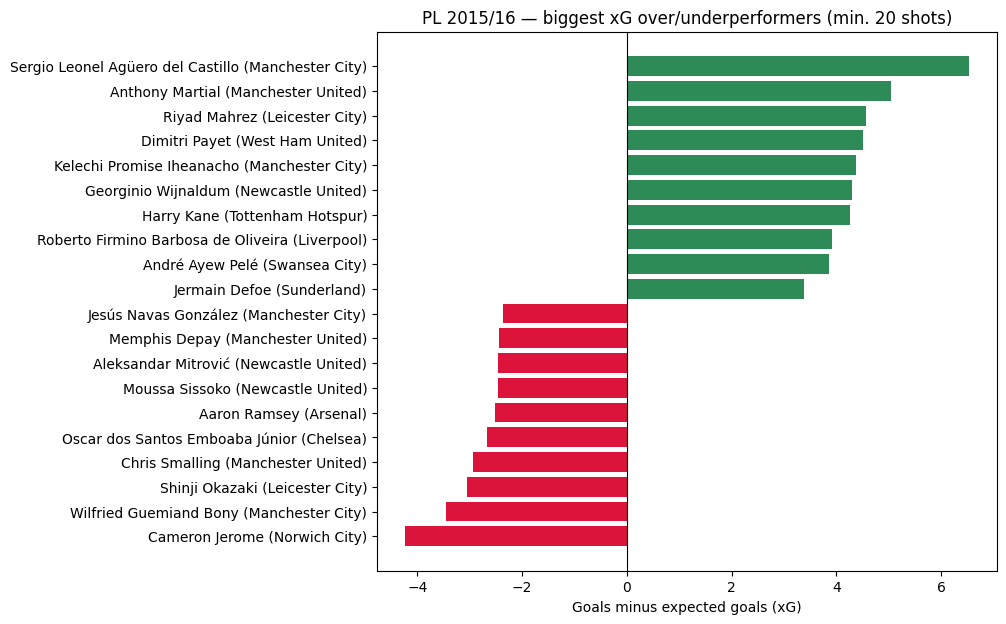

In [10]:
ax = plot_player_xg_ranking(pl_ranking, n=10, title='PL 2015/16 — biggest xG over/underperformers (min. 20 shots)')
ax.figure.savefig('../outputs/pl_2015_16_xg_ranking.png', dpi=150, bbox_inches='tight')

## S4 takeaways

- Gradient boosting, even tuned, didn't beat the logistic baseline out-of-sample on this dataset
  size — logistic regression stays the recommended model. Worth re-testing once more seasons are
  added (S5+), since boosting tends to need more data to earn its complexity.
- Feature importance confirms angle and distance to goal dominate shot quality, with `is_penalty`
  and `assist_Through Ball` as the next strongest signals — consistent with the logistic
  coefficients reviewed in S3.
- PL 2015/16 player rankings line up with what actually happened that season (see the ranking
  table/chart above) — a sanity check that the model's outputs are usable, not just numerically
  plausible.
- Next session (S5): player similarity features — per-90 event metrics + SkillCorner physical
  metrics, `src/similarity.py` skeleton.